In [16]:
import pkg_resources
import pip
installedPackages = {pkg.key for pkg in pkg_resources.working_set} # list of installed packages

required = {'yfinance', 'pandas','numpy', 'matplotlib','stockstats'}
missing = required - installedPackages
if missing:
    !pip install yfinance
    !pip install pandas
    !pip install numpy
    !pip install matplotlib
    !pip install stockstats

In [2]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir("drive/My Drive/Asset_Allocation")

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import yfinance as yf
from pandas_datareader import data as pdr
from stockstats import StockDataFrame as sdf

%matplotlib inline
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [17]:
# Select companies
#https://stockanalysis.com/list/dow-jones-stocks/ date= 2025-01-08
dow_30_companies = [
    ("3M", "MMM"), ("American Express", "AXP"), ("Amgen", "AMGN"), ("Apple", "AAPL"),
    ("Boeing", "BA"), ("Caterpillar", "CAT"), ("Chevron", "CVX"), ("Cisco", "CSCO"),
    ("Coca-Cola", "KO"), ("Amazon", "AMZN"), ("Goldman Sachs", "GS"),
    ("Home Depot", "HD"), ("Honeywell", "HON"), ("IBM", "IBM"), #("Intel", "INTC"),
    ("Johnson & Johnson", "JNJ"), ("JPMorgan Chase", "JPM"), ("McDonald's", "MCD"),
    ("Merck", "MRK"), ("Microsoft", "MSFT"), ("Nike", "NKE"), ("Procter & Gamble", "PG"),
    ("Salesforce", "CRM"), ("Travelers", "TRV"), ("UnitedHealth", "UNH"), ("Verizon", "VZ"),
    ("Visa", "V"), ("Walmart", "WMT"), ("Walt Disney", "DIS"),("NVIDIA","NVDA"),("The Sherwin-Williams","SHW")
]
dow_tickers = [company[1] for company in dow_30_companies]
start_date = "2009-09-01"
end_date = "2025-01-01"
print(len(dow_tickers))

30


In [18]:
# Get ecomonical indicators
start = start_date
end = end_date

# List of FRED codes for economic indicators https://fred.stlouisfed.org/
economic_indicators = {
    "GDP": "GDP",#Gross Domestic Product
    "Unemployment Rate": "UNRATE",#Civilian Unemployment Rate
    "Consumer Price Index": "CPIAUCSL",#	Consumer Price Index for All Urban Consumers: All Items
    "Federal Funds Rate": "FEDFUNDS",#Effective Federal Funds Rate,
    "Interest Rate":"DFF",
    "Federal Debt":"GFDEBTN"#Federal Debt: Total Public Debt
}

# Download economic indicator data
df_economic = pd.DataFrame()
for name, code in economic_indicators.items():
    df_economic[name] = pdr.get_data_fred(code, start, end)


# Export to Excel
df_economic.reset_index(inplace=True)
df_economic.head()

,DATE,GDP,Unemployment Rate,Consumer Price Index,Federal Funds Rate,Interest Rate,Federal Debt
0,2009-10-01,14651.249,10.0,216.509,0.12,0.11,12311349
1,2010-01-01,14764.610,9.8,217.488,0.11,0.05,12773123
2,2010-04-01,14980.193,9.9,217.403,0.20,0.17,13201792
3,2010-07-01,15141.607,9.4,217.605,0.18,0.17,13561622
4,2010-10-01,15309.474,9.4,219.035,0.19,0.20,14025215


In [19]:
#Interpolate to each month, economical indicators are updated each 3 months
monthly_date_range = pd.date_range(start=start_date, end=end_date, freq='MS')
economic_ind = pd.DataFrame({'DATE':monthly_date_range})
economic_ind = pd.merge(economic_ind, df_economic, on=['DATE'], how='left')
economic_ind.interpolate(inplace=True)
economic_ind.columns = economic_ind.columns.str.lower()
economic_ind.head()

,date,gdp,unemployment rate,consumer price index,federal funds rate,interest rate,federal debt
0,2009-09-01,NaN,NaN,NaN,NaN,NaN,NaN
1,2009-10-01,14651.249,10.000000,216.509000,0.120000,0.11,1.231135e+07
2,2009-11-01,14689.036,9.933333,216.835333,0.116667,0.09,1.246527e+07
3,2009-12-01,14726.823,9.866667,217.161667,0.113333,0.07,1.261920e+07
4,2010-01-01,14764.610,9.800000,217.488000,0.110000,0.05,1.277312e+07


In [21]:
#Get monthly prices
data = yf.download(dow_tickers, start=start_date, end=end_date,interval='1mo',multi_level_index=False)
data = data.stack().reset_index()
data.columns = data.columns.str.lower()
data.rename(columns={'ticker':'tic'}, inplace=True)
print('Data size', len(data))
data.head()

[*********************100%***********************]  30 of 30 completed
<ipython-input-21-12cef102b539>:3: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  data = data.stack().reset_index()


Data size 5520


Price,date,tic,close,high,low,open,volume
0,2009-09-01,AAPL,5.583982,5.690931,4.944090,5.060982,9989319200
1,2009-09-01,AMGN,42.356438,43.966869,40.535033,41.920427,133292100
2,2009-09-01,AMZN,4.668000,4.725000,3.875500,4.037000,2562436000
3,2009-09-01,AXP,27.053015,29.127876,25.281401,26.797647,250193200
4,2009-09-01,BA,41.827251,42.854586,36.891402,38.011430,109453100


In [22]:
#Calculate monthly returns
data['monthly_return'] = data.groupby('tic')['close'].pct_change()
data['target'] = data.groupby('tic')['monthly_return'].shift(-1)
data.head()

Price,date,tic,close,high,low,open,volume,monthly_return,target
0,2009-09-01,AAPL,5.583982,5.690931,4.944090,5.060982,9989319200,NaN,0.016995
1,2009-09-01,AMGN,42.356438,43.966869,40.535033,41.920427,133292100,NaN,-0.109746
2,2009-09-01,AMZN,4.668000,4.725000,3.875500,4.037000,2562436000,NaN,0.272601
3,2009-09-01,AXP,27.053015,29.127876,25.281401,26.797647,250193200,NaN,0.033201
4,2009-09-01,BA,41.827251,42.854586,36.891402,38.011430,109453100,NaN,-0.117266


In [27]:
# Calculate technical indicators
#https://pypi.org/project/stockstats/
indicators = [
    #'monthly_return_-1_s', # lagged data
    "monthly_return_6_sma",  # Simple Moving Average
    "monthly_return_3_sma",  # Simple Moving Average
    "close_3_sma",  # Simple Moving Average
    "close_6_sma",  # Simple Moving Average
    "close_3_ema",  # Exponential Moving Average
    "monthly_return_6_mstd",  # Moving Standard Deviation
    "close_6_mstd",  # Moving Standard Deviation
    "monthly_return_3_mvar",  # Moving Variance
    "close_3_mvar",  # Moving Variance
    "rsi",  # Relative Strength Index
    "kdjk",  # Stochastic Oscillator k series
    "boll",  # Bollinger Bands
    "macd",  # Moving Average Convergence Divergence
    "wr",  # Williams Overbought/Oversold index is a type of momentum indicator
    "cci",  # Commodity Channel Index
    "tr",  # True Range
    "atr",  # Average True Range: TR is a measure of the volatility of a High-Low-Close series. It is used for calculating the ATR.
    "dx",  # Directional Movement Index,  the directional index (DX)
    "adx",  # Average Directional Movement Index
    "trix",  # Triple Exponential Moving Average
    "vwma",  # Volume Weighted Moving Average
    "chop",  # Choppiness Index
    #"monthly_return_3_kama",  # Kaufman's Adaptive Moving Average
    "close_3_kama",  # Kaufman's Adaptive Moving Average is  designed to account for market noise or volatility.
    "ppo",  # Percentage Price Oscillator
    #"stochrsi",  # Stochastic RSI
    "supertrend",  # Supertrend
    "aroon",  # Aroon Oscillator
    "ao",  # Awesome Oscillator
    #"bop",  # Balance of Power
    "close_3_roc",  # The Price Rate of Change (ROC) is a momentum-based technical indicator
    "cti", #Correlation Trend Indicator
    "ichimoku",  # Ichimoku Cloud show momentum and trend direction.
    #"eri",  # Elder-Ray Index
    "rvgi",  # Relative Vigor Index is a momentum indicator
    "kst",  # Know Sure Thing is a momentum oscillator
    #"pgo",  # Pretty Good Oscillator
    "pvo",  # Percentage Volume Oscillator is a momentum oscillator for volume.
    "qqe",  # Quantitative Qualitative Estimation is smoother version RSI,QQE expands on RSI by adding two volatility based trailing stop lines.
    'cmo',#The Chande Momentum Oscillator (CMO) is a technical momentum indicator
    'coppock',#Coppock Curve is a momentum indicator
    'ker', # KER = window_change / volatility
    'change',
    #'rs_14',
    'rsi_3',
    'rsi_6',
    'rsi_14',
    'rate',
    'middle',
    'tp',
    'boll_ub',
    'boll_lb',
    'macds',
    'macdh',
    'ppos',
    'ppoh',
    'rsv_9',
    'kdjk_9',
    'kdjd_9',
    'kdjd',
    'kdjj_9',
    'kdjj',
    'cr',
    'cr-ma1',
    'cr-ma2',
    'cr-ma3',
    'high_delta',
    #'um',
    'low_delta',
    #'dm',
    'atr_6',
    #'pdm',
    #'pdm_6_ema',
    #'pdm_6',
    'pdi_6',
    #'pdm_14_ema',
    'pdm_14',
    'atr_14',
    'pdi_14',
    'pdi',
    #'mdm',
    #'mdm_14_ema',
    #'mdm_14',
    #'mdi_14',
    #'mdi',
    'dx_14',
    'adxr',
    #'mdm_6_ema',
    #'mdm_6',
    #'mdi_6',
    'dx_6',
    'tema',
    'vr',
    'close_10_sma',
    'close_50_sma',
    'dma',
    'log-ret',
    'mfi',
    'wt1',
    'wt2',
    'supertrend_ub',
    'supertrend_lb',
    'vwma_3'
]

# Initialize an empty DataFrame to store results
results = pd.DataFrame()

# Group by ticker
grouped = data.groupby('tic')

for ticker, group in grouped:
    stock_df = sdf.retype(group)
    #stock_df.init_all()
    for i in indicators:
      group[i] = stock_df[i]
    results = pd.concat([results, group])

results.head()

Output hidden; open in https://colab.research.google.com to view.

In [42]:
results.shape, len(indicators)

((5520, 91), 83)

In [28]:
#check value counts
data = results.copy()
data.tic.nunique(),data.tic.value_counts()

(30,
 tic
 AAPL    184
 AMGN    184
 VZ      184
 V       184
 UNH     184
 TRV     184
 SHW     184
 PG      184
 NVDA    184
 NKE     184
 MSFT    184
 MRK     184
 MMM     184
 MCD     184
 KO      184
 JPM     184
 JNJ     184
 IBM     184
 HON     184
 HD      184
 GS      184
 DIS     184
 CVX     184
 CSCO    184
 CRM     184
 CAT     184
 BA      184
 AXP     184
 AMZN    184
 WMT     184
 Name: count, dtype: int64)

In [29]:
# get economic indicators
data = pd.merge(data, economic_ind, on=['date'], how='left')
data.head()

,date,tic,close,high,low,open,volume,monthly_return,target,monthly_return_6_sma,monthly_return_3_sma,close_3_sma,close_6_sma,close_3_ema,monthly_return_6_mstd,close_6_mstd,monthly_return_3_mvar,close_3_mvar,rsi,kdjk,boll,macd,wr,cci,tr,atr,dx,adx,trix,vwma,chop,close_3_kama,ppo,supertrend,aroon,ao,close_3_roc,cti,ichimoku,rvgi,kst,pvo,qqe,cmo,coppock,ker,change,rsi_3,rsi_6,rsi_14,rate,middle,tp,boll_ub,boll_lb,macds,macdh,ppos,ppoh,rsv_9,kdjk_9,kdjd_9,kdjd,kdjj_9,kdjj,cr,cr-ma1,cr-ma2,cr-ma3,high_delta,low_delta,atr_6,pdi_6,pdm_14,atr_14,pdi_14,pdi,dx_14,adxr,dx_6,tema,vr,close_10_sma,close_50_sma,dma,log-ret,mfi,wt1,wt2,supertrend_ub,supertrend_lb,vwma_3,gdp,unemployment rate,consumer price index,federal funds rate,interest rate,federal debt
0,2009-09-01,AAPL,5.583982,5.690931,4.944090,5.060982,9989319200,NaN,0.016995,NaN,NaN,5.583982,5.583982,5.583982,NaN,NaN,NaN,NaN,NaN,61.893239,5.583982,0.000000,-14.320284,NaN,0.746841,0.746841,NaN,NaN,0.000000,5.406334,0.000000,5.583982,0.000000,7.558034,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,NaN,NaN,NaN,NaN,5.406334,5.406334,NaN,NaN,0.000000,0.000000,0.000000,0.000000,85.679716,61.893239,53.964413,53.964413,77.750891,77.750891,61.568536,61.568536,61.568536,61.568536,0.000000,0.000000,0.746841,0.000000,0.000000,0.746841,0.000000,0.000000,NaN,NaN,NaN,5.583982,100.000000,5.583982,5.583982,0.0,0.000000,0.5,NaN,NaN,7.558034,3.076987,5.406334,NaN,NaN,NaN,NaN,NaN,NaN
1,2009-10-01,AAPL,5.678882,6.287742,5.443893,5.583983,12956176800,0.016995,0.060530,0.016995,0.016995,5.631432,5.631432,5.647248,NaN,0.067105,NaN,0.004503,100.000000,59.490872,5.631432,0.002129,-45.313862,66.666667,0.843849,0.797142,100.0,100.0,0.270097,5.630597,6.395345,5.631432,0.037796,7.558034,4.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.577322,0.0,100.000000,0.0,1.000000,1.699507,100.000000,100.000000,100.000000,1.699507,5.803506,5.803506,5.765641,5.497223,0.001183,0.000946,0.020998,0.016798,54.686138,59.490872,55.806566,55.806566,66.859484,66.859484,252.248723,61.568536,61.568536,61.568536,0.596811,0.499803,0.799755,40.704142,0.309458,0.797142,38.820899,38.820899,100.0,100.0,100.0,5.672808,359.400597,5.631432,5.631432,0.0,0.016852,0.5,121.212121,121.212121,7.558034,3.474392,5.630597,14651.249,10.000000,216.509000,0.120000,0.11,1.231135e+07
2,2009-11-01,AAPL,6.022626,6.266351,5.590609,5.718045,8454784800,0.060530,0.054124,0.038763,0.038763,5.761830,5.761830,5.861750,0.030784,0.230787,0.000948,0.053263,100.000000,66.416916,5.761830,0.013372,-19.730996,74.669727,0.675741,0.753642,100.0,100.0,0.564269,5.719254,19.810685,5.761830,0.231632,7.558034,4.0,0.0,0.000000,0.0,0.0,0.000000,0.0,-0.525392,0.0,100.000000,0.0,1.000000,6.053036,100.000000,100.000000,100.000000,6.053036,5.959862,5.959862,6.223404,5.300256,0.006179,0.007194,0.107324,0.124309,80.269004,66.416916,59.343349,59.343349,80.564049,80.564049,241.260985,61.568536,61.568536,61.568536,-0.021392,0.146717,0.750695,26.209183,0.198573,0.753642,26.348504,26.348504,100.0,100.0,100.0,5.978080,528.677093,5.761830,5.761830,0.0,0.058769,0.5,107.940097,114.576109,7.558034,3.667555,5.719254,14689.036,9.933333,216.835333,0.116667,0.09,1.246527e+07
3,2009-12-01,AAPL,6.348597,6.445604,5.684303,6.092821,11393958800,0.054124,-0.088597,0.043883,0.043883,6.016702,5.908522,6.121402,0.023505,0.348686,0.000552,0.112156,100.000000,75.457724,5.908522,0.029927,-6.460661,95.933140,0.761301,0.755774,100.0,100.0,0.779148,5.836470,26.575404,6.153008,0.504337,7.558034,12.0,0.0,13.693008,0.0,0.0,0.346959,0.0,-0.023355,0.0,100.000000,0.0,1.000000,5.412426,100.000000,100.000000,100.000000,5.412426,6.159501,6.159501,6.605894,5.211149,0.014224,0.015704,0.241813,0.262524,93.539339,75.457724,64.714807,64.714807,96.943556,96.943556,222.424916,61.568536,61.568536,61.568536,0.179253,0.093694,0.754109,25.343601,0.193194,0.755774,25.562384,25.562384,100.0,100.0,100.0,6.308710,756.799923,5.908522,5.908522,0.0,0.052710,0.5,104.438253,111.196824,7.558034,3.797630,5.967449,14726.8

In [30]:
data.rename(columns={'tic': 'Ticker','date':'Date'}, inplace=True)

<Axes: xlabel='Date'>

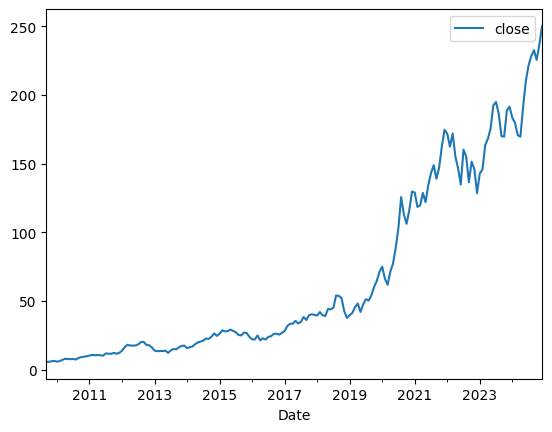

In [31]:
data[data.Ticker == 'AAPL'].plot.line(y=["close"], x='Date')

<Axes: xlabel='Date'>

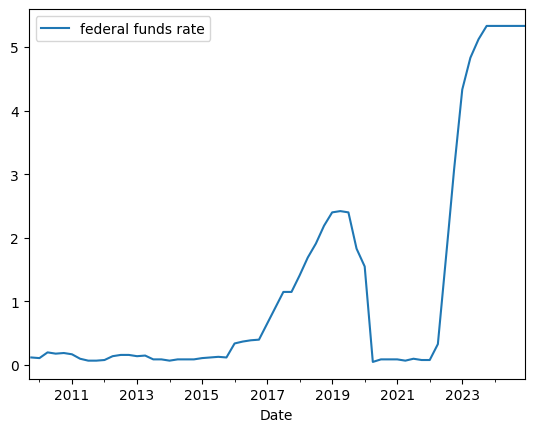

In [32]:
data[data.Ticker == 'AAPL'].plot.line(y=["federal funds rate"], x='Date')

In [33]:
data.Date.min(),data.Date.max()

(Timestamp('2009-09-01 00:00:00'), Timestamp('2024-12-01 00:00:00'))

<Axes: xlabel='Date'>

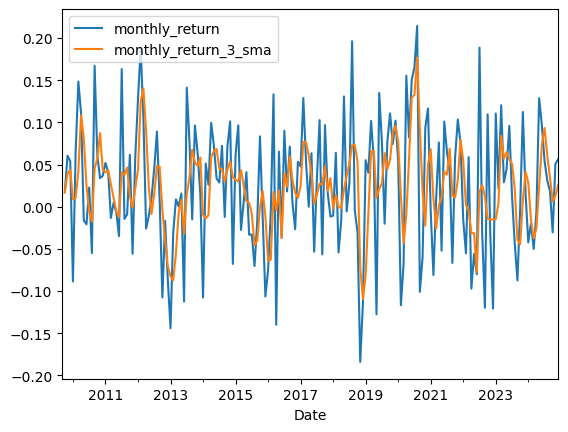

In [34]:
data[data.Ticker == 'AAPL'].plot.line(y=["monthly_return",'monthly_return_3_sma'], x='Date')

In [35]:
train_df = data[(data.Date>='2010-01-01') & (data.Date<='2021-12-01')]
test_df = data[('2021-12-01'<data.Date) & (data.Date<'2024-12-01')] # update to 2025-01-01
train_df.Date.nunique(),test_df.Date.nunique()

(144, 35)

In [36]:
#Check train test ratio
train_df.Date.nunique()/test_df.Date.nunique()

4.114285714285714

In [37]:
#check NaN values
train_df.isna().sum().sum(),test_df.isna().sum().sum()

(0, 0)

In [38]:
#check dates
test_df.Date.min(),test_df.Date.max(),train_df.Date.min(),train_df.Date.max()

(Timestamp('2022-01-01 00:00:00'),
 Timestamp('2024-11-01 00:00:00'),
 Timestamp('2010-01-01 00:00:00'),
 Timestamp('2021-12-01 00:00:00'))

In [39]:
#check shape
test_df.shape,train_df.shape

((1050, 98), (4320, 98))

In [40]:
train_df.to_pickle('datasets/train_data_m1_month.pkl')
test_df.to_pickle('datasets/test_data_m1_month.pkl')